## 0. Install & Import Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

# Plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

## 1. Configuration & Label Mapping

In [2]:
# ─────────────────────────────────────────────
#  SET THIS to your local dataset root folder
# ─────────────────────────────────────────────
DATASET_ROOT = './dataset'   # <-- change this path
SAMPLING_RATE = 64_000              # 64 kHz
WINDOW_SIZE   = 6400                # 0.1 second window
OVERLAP       = 0                # 50% overlap between windows
STEP          = int(WINDOW_SIZE * (1 - OVERLAP))


BEARING_META = {
    # Healthy
    'K001': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    'K002': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    'K003': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    'K004': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    'K005': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    'K006': {'condition': 0, 'label': 'Healthy', 'location': 'None',  'severity': 0, 'damage_type': 'None'},
    # Artificially Damaged
    'KA01': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 1, 'damage_type': 'EDM'},
    'KA03': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 2, 'damage_type': 'EDM'},
    'KA05': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 1, 'damage_type': 'Drilling'},
    'KA06': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 2, 'damage_type': 'Drilling'},
    'KA07': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 1, 'damage_type': 'EDM'},
    'KA08': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 2, 'damage_type': 'Engraving'},
    'KA09': {'condition': 1, 'label': 'Artificial', 'location': 'OR', 'severity': 2, 'damage_type': 'Engraving'},
    'KI01': {'condition': 1, 'label': 'Artificial', 'location': 'IR', 'severity': 1, 'damage_type': 'EDM'},
    'KI03': {'condition': 1, 'label': 'Artificial', 'location': 'IR', 'severity': 2, 'damage_type': 'EDM'},
    'KI05': {'condition': 1, 'label': 'Artificial', 'location': 'IR', 'severity': 1, 'damage_type': 'Drilling'},
    'KI07': {'condition': 1, 'label': 'Artificial', 'location': 'IR', 'severity': 1, 'damage_type': 'EDM'},
    'KI08': {'condition': 1, 'label': 'Artificial', 'location': 'IR', 'severity': 2, 'damage_type': 'Engraving'},
    # Real Damages (most important for car prediction)
    'KA04': {'condition': 2, 'label': 'Real',       'location': 'OR', 'severity': 1, 'damage_type': 'Fatigue'},
    'KA15': {'condition': 2, 'label': 'Real',       'location': 'OR', 'severity': 1, 'damage_type': 'Fatigue'},
    'KA16': {'condition': 2, 'label': 'Real',       'location': 'OR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KA22': {'condition': 2, 'label': 'Real',       'location': 'OR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KA30': {'condition': 2, 'label': 'Real',       'location': 'OR', 'severity': 2, 'damage_type': 'Plastic Def.'},
    'KB23': {'condition': 2, 'label': 'Real',       'location': 'OR+IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KB24': {'condition': 2, 'label': 'Real',       'location': 'OR+IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KB27': {'condition': 2, 'label': 'Real',       'location': 'OR+IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KI04': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 1, 'damage_type': 'Fatigue'},
    'KI14': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 1, 'damage_type': 'Fatigue'},
    'KI15': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KI16': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KI17': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KI18': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 2, 'damage_type': 'Fatigue'},
    'KI21': {'condition': 2, 'label': 'Real',       'location': 'IR', 'severity': 2, 'damage_type': 'Fatigue'},
}

print(f'Total bearing codes defined: {len(BEARING_META)}')
print(f'Window size: {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE*1000:.0f} ms')
print(f'Step size:   {STEP} samples ({int((1-OVERLAP)*100)}% non-overlap)')

Total bearing codes defined: 33
Window size: 6400 samples = 100 ms
Step size:   6400 samples (100% non-overlap)


## 2. Data Loading Functions

In [3]:
def parse_filename(fname):
    """
    Parse a .mat filename like N15_M07_F10_KA01_1.mat
    Returns a dict with operating condition details.
    """
    base = os.path.splitext(fname)[0]
    parts = base.split('_')
    speed_map  = {'N15': 1500, 'N09': 900}
    torque_map = {'M07': 0.7,  'M01': 0.1}
    force_map  = {'F10': 1000, 'F04': 400}
    return {
        'speed_rpm':   speed_map.get(parts[0], None),
        'torque_Nm':   torque_map.get(parts[1], None),
        'force_N':     force_map.get(parts[2], None),
        'bearing_code': parts[3],
        'meas_index':  int(parts[4]) if len(parts) > 4 else None,
        'filename':    fname
    }


def load_mat_file(filepath):
    """
    Fixed loader based on actual Paderborn .mat file structure.
    Channels are in Y list, accessed by Name field.
    """
    mat = loadmat(filepath, simplify_cells=True)
    data_key = [k for k in mat.keys() if not k.startswith('_')][0]
    data = mat[data_key]
    Y = data['Y']

    signals = {}
    for channel in Y:
        name = channel['Name']
        signals[name] = np.array(channel['Data']).flatten().astype(float)

    return {
        'vibration': signals.get('vibration_1', np.zeros(256001)),
        'current_1': signals.get('phase_current_1', np.zeros(256001)),
        'current_2': signals.get('phase_current_2', np.zeros(256001)),
        'speed':     signals.get('speed', np.zeros(16001)),
        'torque':    signals.get('torque', np.zeros(16001)),
        'force':     signals.get('force', np.zeros(16001)),
    }

def scan_dataset(root):
    """
    Walk through the dataset root and collect all .mat file paths.
    Returns a list of dicts with path + parsed metadata.
    """
    records = []
    for folder in sorted(os.listdir(root)):
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in sorted(os.listdir(folder_path)):
            if fname.endswith('.mat'):
                meta = parse_filename(fname)
                bearing_code = meta['bearing_code']
                if bearing_code in BEARING_META:
                    meta.update(BEARING_META[bearing_code])
                    meta['filepath'] = os.path.join(folder_path, fname)
                    records.append(meta)
    return records


# Scan and show summary
all_files = scan_dataset(DATASET_ROOT)
files_df  = pd.DataFrame(all_files)
print(f'Total .mat files found: {len(files_df)}')
print('\nBreakdown by label:')
print(files_df['label'].value_counts())
files_df.head()

Total .mat files found: 2480

Breakdown by label:
label
Real          1040
Artificial     960
Healthy        480
Name: count, dtype: int64


,speed_rpm,torque_Nm,force_N,bearing_code,meas_index,filename,condition,label,location,severity,damage_type,filepath
0,900,0.7,1000,K001,1,N09_M07_F10_K001_1.mat,0,Healthy,None,0,None,./dataset\K001\N09_M07_F10_K001_1.mat
1,900,0.7,1000,K001,10,N09_M07_F10_K001_10.mat,0,Healthy,None,0,None,./dataset\K001\N09_M07_F10_K001_10.mat
2,900,0.7,1000,K001,11,N09_M07_F10_K001_11.mat,0,Healthy,None,0,None,./dataset\K001\N09_M07_F10_K001_11.mat
3,900,0.7,1000,K001,12,N09_M07_F10_K001_12.mat,0,Healthy,None,0,None,./dataset\K001\N09_M07_F10_K001_12.mat
4,900,0.7,1000,K001,13,N09_M07_F10_K001_13.mat,0,Healthy,None,0,None,./dataset\K001\N09_M07_F10_K001_13.mat


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Distribution

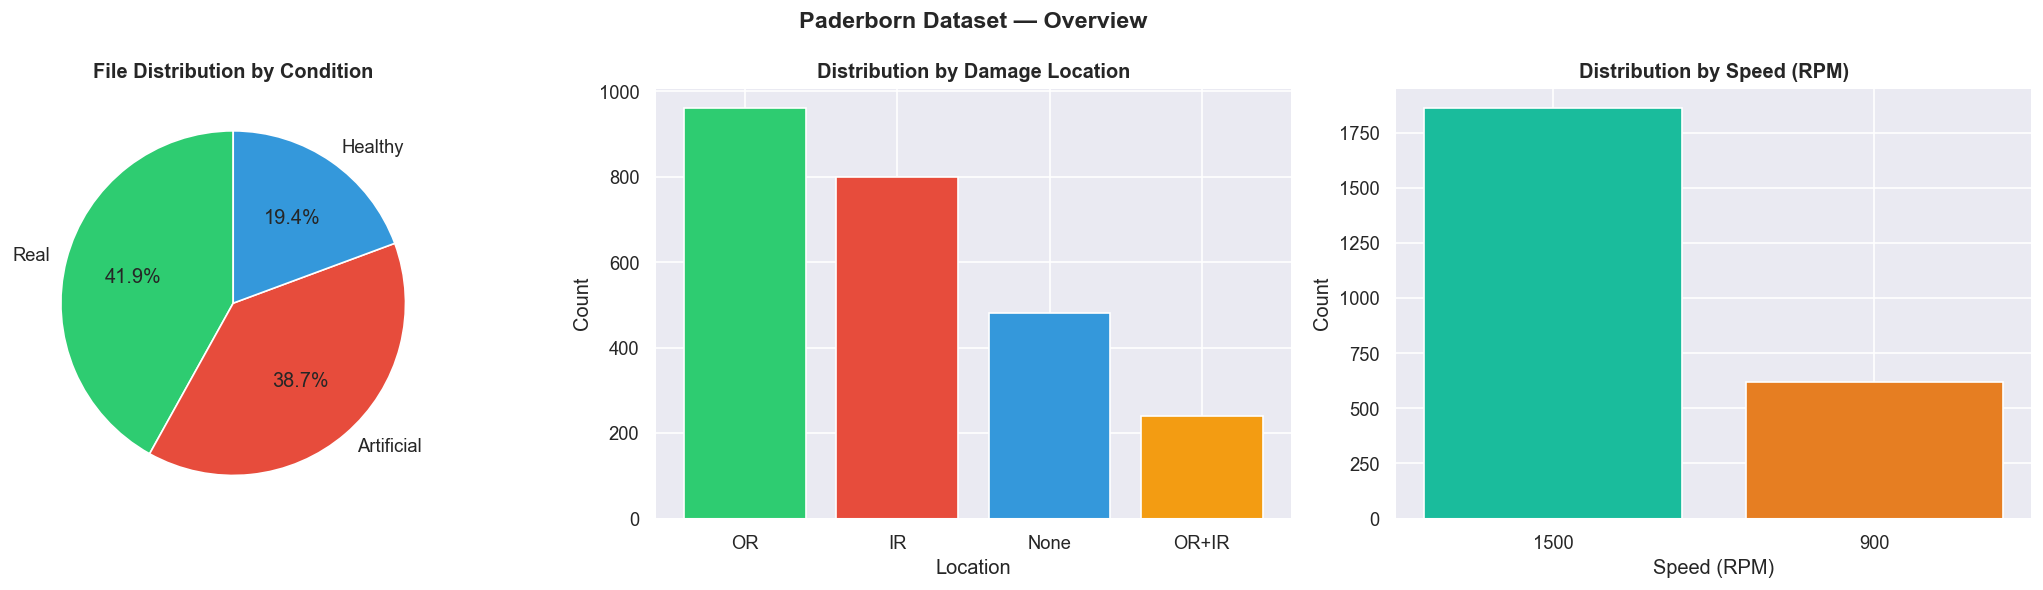

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Condition distribution
cond_counts = files_df['label'].value_counts()
axes[0].pie(cond_counts, labels=cond_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db'], startangle=90)
axes[0].set_title('File Distribution by Condition', fontweight='bold')

# Damage location
loc_counts = files_df['location'].value_counts()
axes[1].bar(loc_counts.index, loc_counts.values,
            color=['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6'])
axes[1].set_title('Distribution by Damage Location', fontweight='bold')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Count')

# Operating condition (speed)
speed_counts = files_df['speed_rpm'].value_counts()
axes[2].bar(speed_counts.index.astype(str), speed_counts.values,
            color=['#1abc9c', '#e67e22'])
axes[2].set_title('Distribution by Speed (RPM)', fontweight='bold')
axes[2].set_xlabel('Speed (RPM)')
axes[2].set_ylabel('Count')

plt.suptitle('Paderborn Dataset — Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Raw Signal Visualization (Healthy vs Damaged)

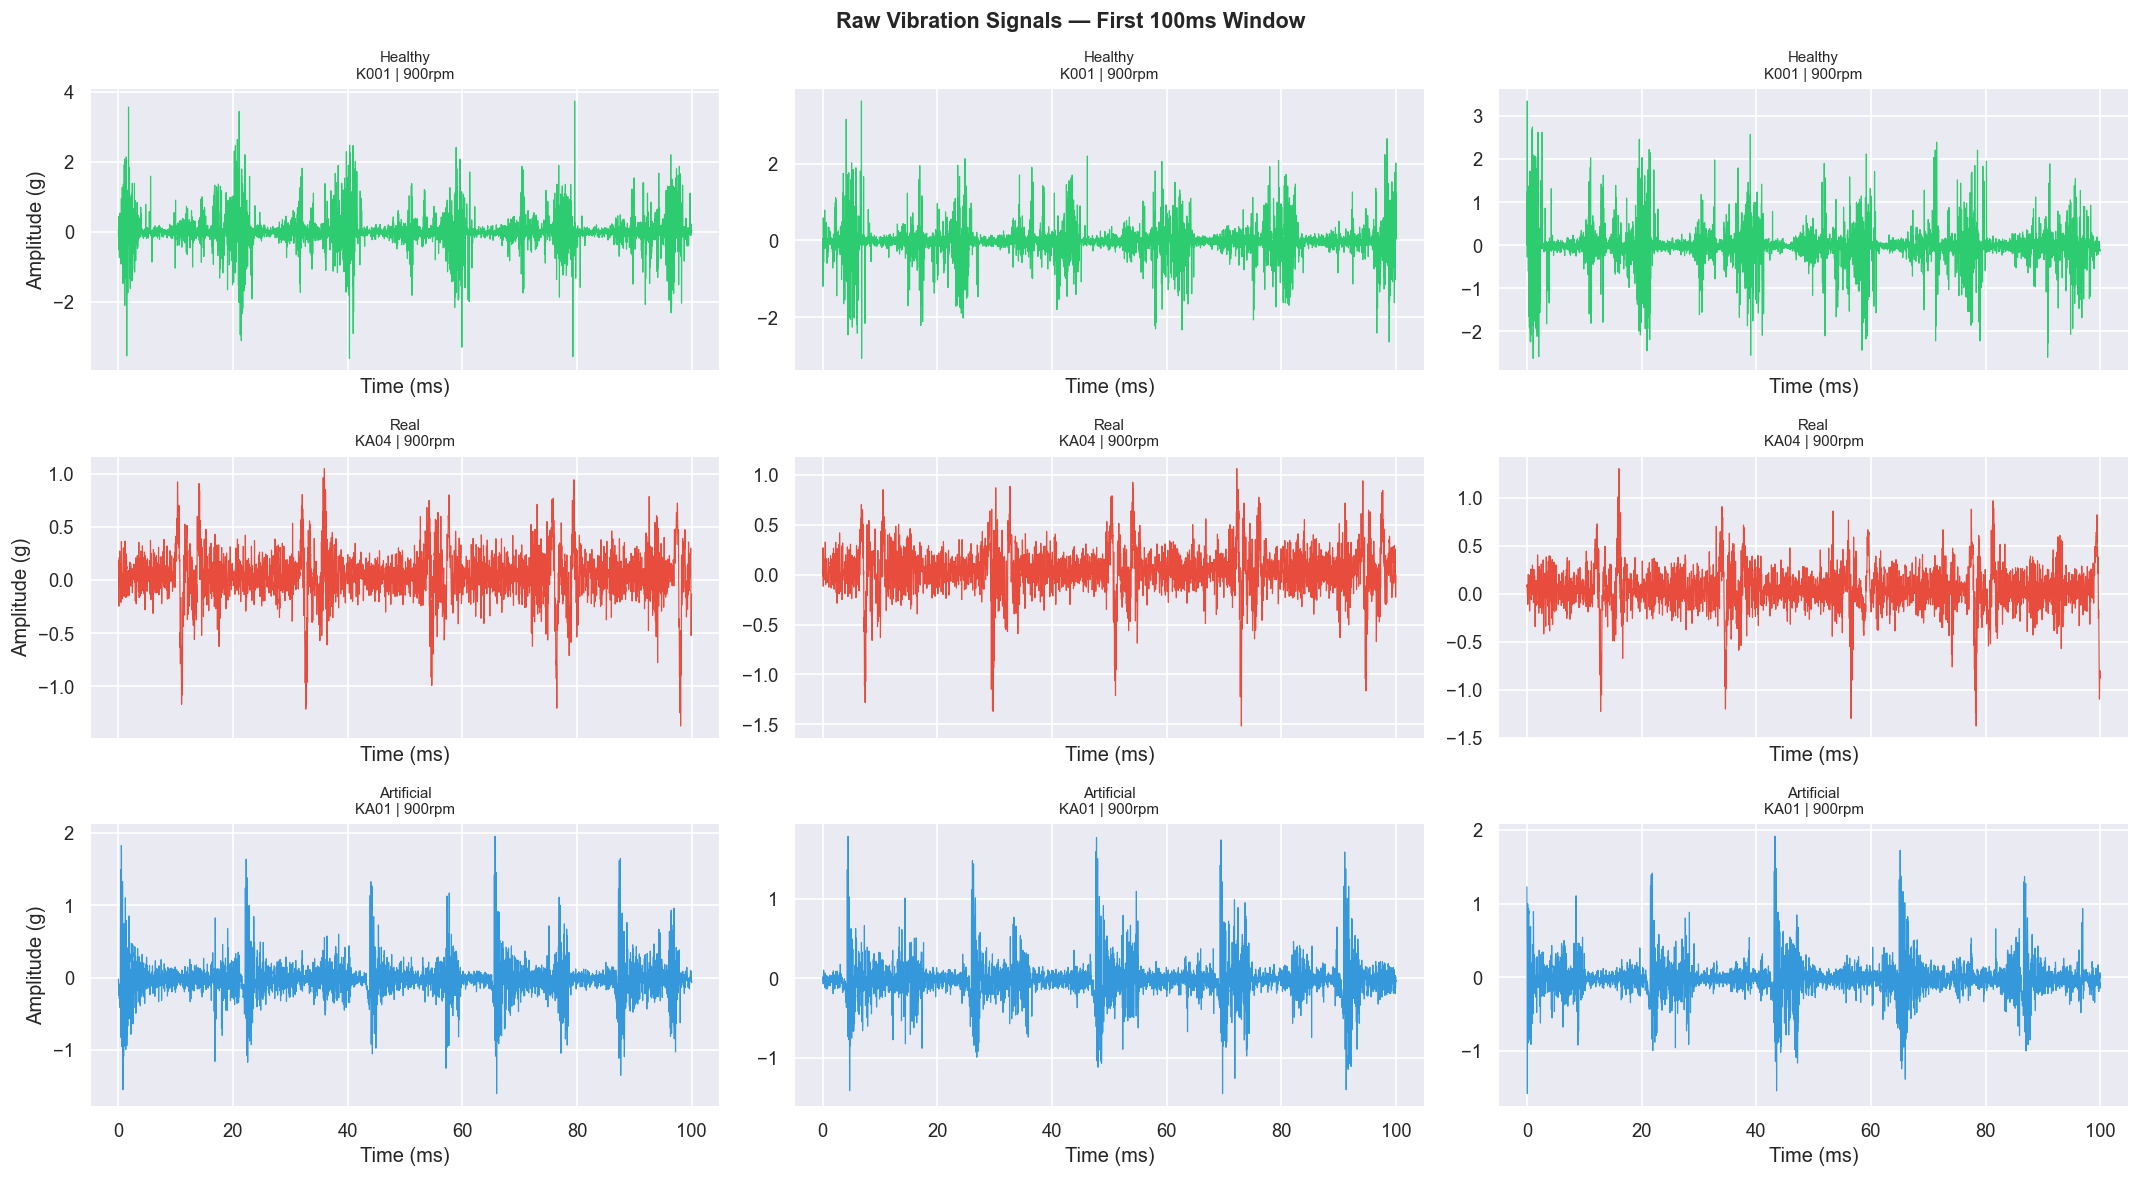

In [5]:
def plot_raw_signals(files_df, n_samples=3):
    categories = [
        ('Healthy',    '#2ecc71'),
        ('Real',       '#e74c3c'),
        ('Artificial', '#3498db'),
    ]
    fig, axes = plt.subplots(len(categories), n_samples,
                              figsize=(18, 10), sharex=True)
    t = np.arange(WINDOW_SIZE) / SAMPLING_RATE * 1000  # ms

    for row, (label, color) in enumerate(categories):
        subset = files_df[files_df['label'] == label].head(n_samples)
        for col, (_, row_data) in enumerate(subset.iterrows()):
            try:
                signals = load_mat_file(row_data['filepath'])
                vib = signals['vibration'][:WINDOW_SIZE]
            except Exception as e:
                vib = np.zeros(WINDOW_SIZE)
            axes[row, col].plot(t, vib, color=color, linewidth=0.7)
            axes[row, col].set_title(
                f"{label}\n{row_data['bearing_code']} | {row_data['speed_rpm']}rpm",
                fontsize=9)
            if col == 0:
                axes[row, col].set_ylabel('Amplitude (g)')
            axes[row, col].set_xlabel('Time (ms)')

    plt.suptitle('Raw Vibration Signals — First 100ms Window', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_raw_signals(files_df)

### 3.3 Frequency Domain (FFT)

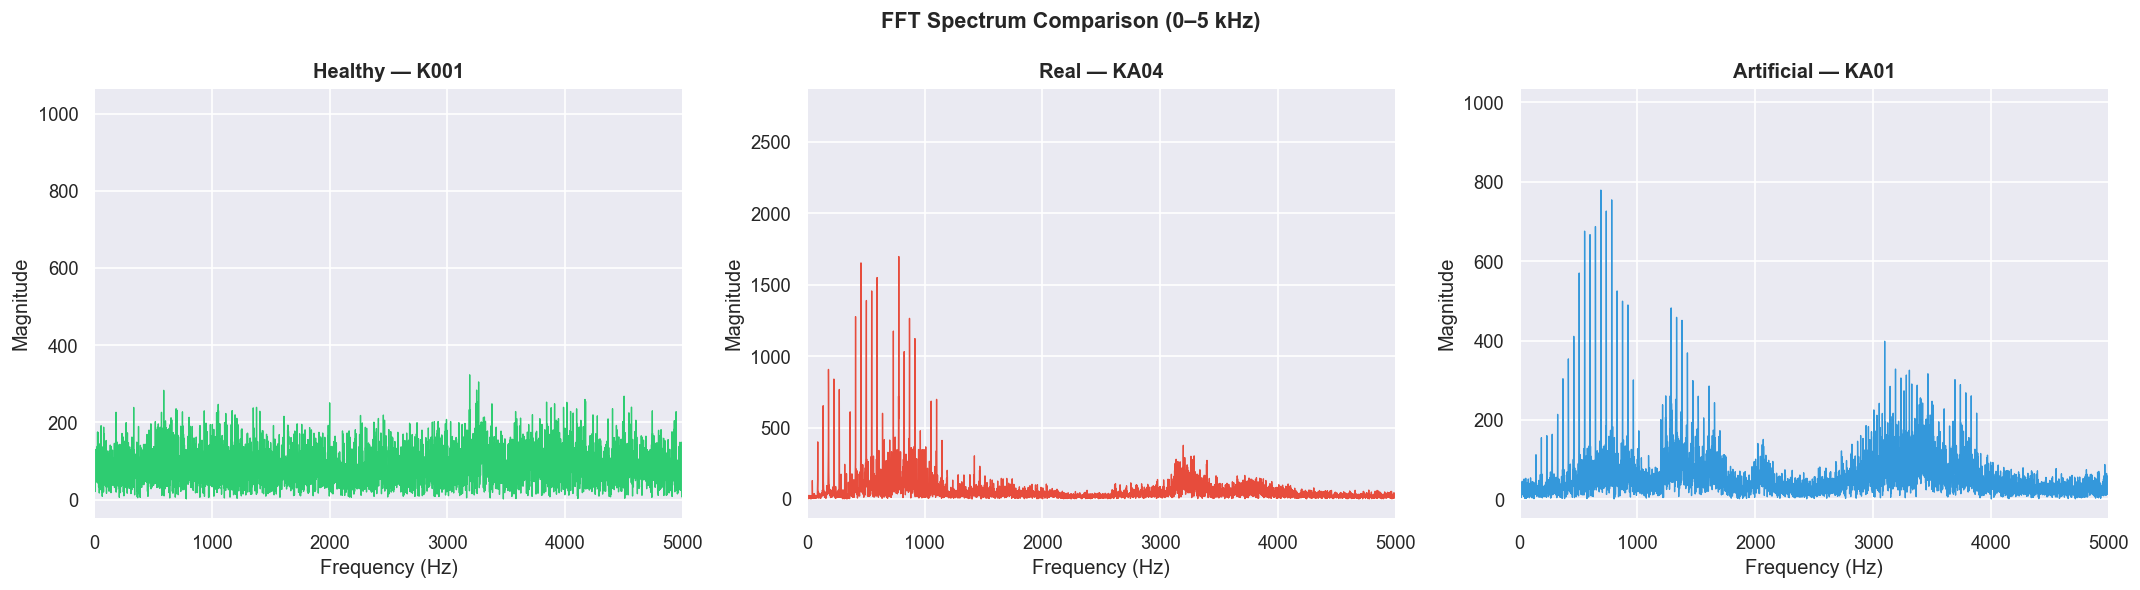

In [6]:
def plot_fft_comparison(files_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels_colors = [('Healthy', '#2ecc71'), ('Real', '#e74c3c'), ('Artificial', '#3498db')]

    for ax, (label, color) in zip(axes, labels_colors):
        sample = files_df[files_df['label'] == label].iloc[0]
        try:
            signals = load_mat_file(sample['filepath'])
            vib = signals['vibration'][:SAMPLING_RATE]  # 1 second
        except:
            vib = np.random.normal(0, 0.01, SAMPLING_RATE)

        freqs = np.fft.rfftfreq(len(vib), 1 / SAMPLING_RATE)
        fft_mag = np.abs(np.fft.rfft(vib))

        ax.plot(freqs[:5000], fft_mag[:5000], color=color, linewidth=0.8)
        ax.set_title(f'{label} — {sample["bearing_code"]}', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_xlim(0, 5000)

    plt.suptitle('FFT Spectrum Comparison (0–5 kHz)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_fft_comparison(files_df)

### 3.4 Power Spectral Density (PSD)

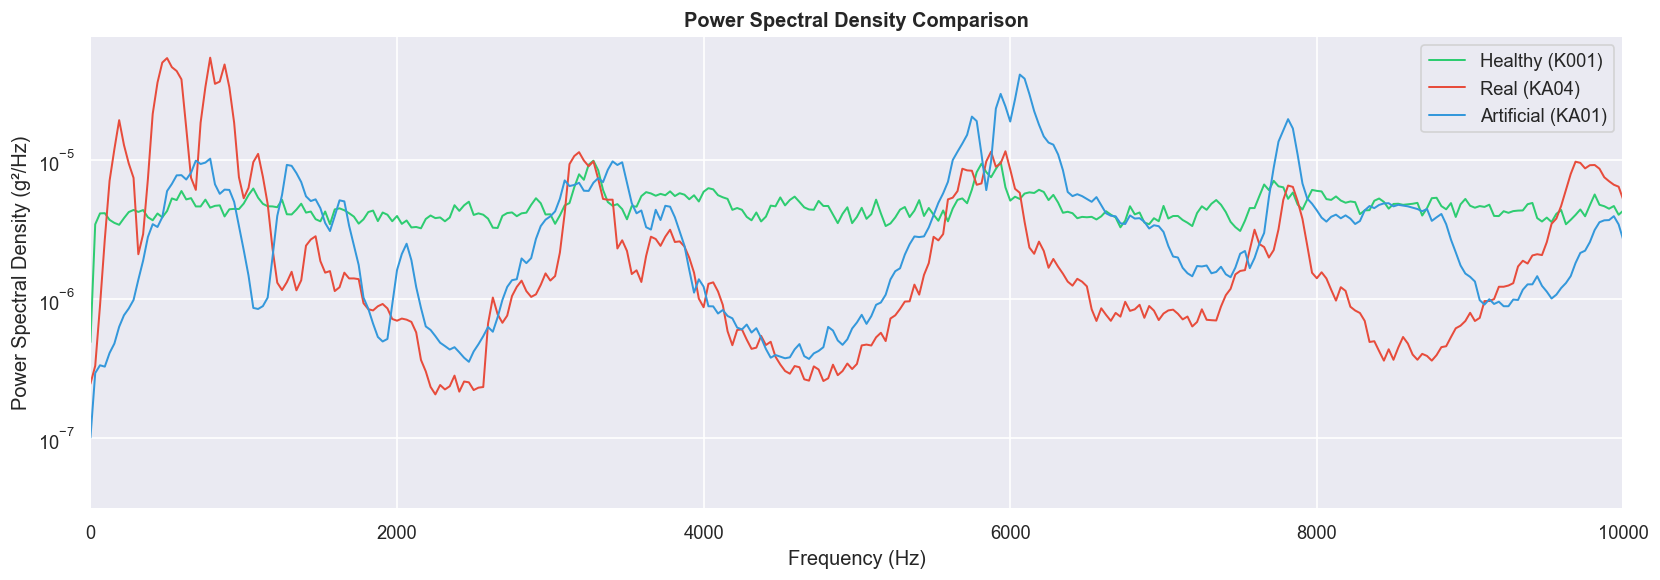

In [7]:
def plot_psd(files_df):
    labels_colors = [('Healthy', '#2ecc71'), ('Real', '#e74c3c'), ('Artificial', '#3498db')]
    fig, ax = plt.subplots(figsize=(14, 5))

    for label, color in labels_colors:
        sample = files_df[files_df['label'] == label].iloc[0]
        try:
            signals = load_mat_file(sample['filepath'])
            vib = signals['vibration'][:SAMPLING_RATE]
        except:
            vib = np.random.normal(0, 0.01, SAMPLING_RATE)

        f, Pxx = welch(vib, fs=SAMPLING_RATE, nperseg=2048)
        ax.semilogy(f, Pxx, label=f'{label} ({sample["bearing_code"]})',
                    color=color, linewidth=1.2)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power Spectral Density (g²/Hz)')
    ax.set_title('Power Spectral Density Comparison', fontweight='bold')
    ax.legend()
    ax.set_xlim(0, 10000)
    plt.tight_layout()
    plt.show()

plot_psd(files_df)

## 4. Feature Extraction (Time + Frequency Domain)

In [8]:
def extract_time_features(signal):
    """Extract statistical time-domain features from a signal window."""
    return {
        'rms':          np.sqrt(np.mean(signal ** 2)),
        'mean':         np.mean(signal),
        'std':          np.std(signal),
        'kurtosis':     kurtosis(signal),
        'skewness':     skew(signal),
        'peak':         np.max(np.abs(signal)),
        'peak_to_peak': np.ptp(signal),
        'crest_factor': np.max(np.abs(signal)) / (np.sqrt(np.mean(signal ** 2)) + 1e-10),
        'shape_factor': np.sqrt(np.mean(signal ** 2)) / (np.mean(np.abs(signal)) + 1e-10),
        'impulse_factor': np.max(np.abs(signal)) / (np.mean(np.abs(signal)) + 1e-10),
    }


def extract_freq_features(signal, fs=SAMPLING_RATE, n_bands=5):
    """Extract frequency-domain features using FFT and PSD."""
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    fft_mag = np.abs(np.fft.rfft(signal))

    # Spectral centroid
    spectral_centroid = np.sum(freqs * fft_mag) / (np.sum(fft_mag) + 1e-10)

    # Spectral bandwidth
    spectral_bandwidth = np.sqrt(
        np.sum(((freqs - spectral_centroid) ** 2) * fft_mag) / (np.sum(fft_mag) + 1e-10)
    )

    # PSD energy in frequency bands
    f_psd, Pxx = welch(signal, fs=fs, nperseg=min(512, N))
    band_edges = np.linspace(0, fs / 2, n_bands + 1)
    band_energies = {}
    for i in range(n_bands):
        mask = (f_psd >= band_edges[i]) & (f_psd < band_edges[i + 1])
        band_energies[f'band_energy_{i}'] = np.sum(Pxx[mask])

    features = {
        'spectral_centroid':   spectral_centroid,
        'spectral_bandwidth':  spectral_bandwidth,
        'spectral_energy':     np.sum(fft_mag ** 2),
        'dominant_freq':       freqs[np.argmax(fft_mag)],
    }
    features.update(band_energies)
    return features


def extract_all_features(signal, fs=SAMPLING_RATE):
    """Combine time and frequency features."""
    feats = {}
    feats.update(extract_time_features(signal))
    feats.update(extract_freq_features(signal, fs))
    return feats


print('Feature extraction functions defined.')
print(f'Time features: {len(extract_time_features(np.random.randn(WINDOW_SIZE)))}')
print(f'Freq features: {len(extract_freq_features(np.random.randn(WINDOW_SIZE)))}')
print(f'Total features per window: {len(extract_all_features(np.random.randn(WINDOW_SIZE)))}')

Feature extraction functions defined.
Time features: 10
Freq features: 9
Total features per window: 19


## 5. Windowing + Full Feature Extraction Pipeline

In [9]:
def process_single_file(file_meta, window_size=WINDOW_SIZE, step=STEP):
    """
    Load a single .mat file, apply sliding window,
    extract features from each window, and return a DataFrame.
    """
    try:
        signals = load_mat_file(file_meta['filepath'])
    except Exception as e:
        print(f"  [SKIP] {file_meta['filename']}: {e}")
        return None

    vib = signals['vibration']
    cur1 = signals['current_1']
    cur2 = signals['current_2']

    # Sliding windows
    windows = []
    for start in range(0, len(vib) - window_size + 1, step):
        end = start + window_size
        w_vib  = vib[start:end]
        w_cur1 = cur1[start:end] if len(cur1) >= end else np.zeros(window_size)
        w_cur2 = cur2[start:end] if len(cur2) >= end else np.zeros(window_size)

        feats = {}
        # Vibration features
        vib_feats = extract_all_features(w_vib)
        feats.update({f'vib_{k}': v for k, v in vib_feats.items()})
        # Current 1 features
        cur1_feats = extract_all_features(w_cur1)
        feats.update({f'cur1_{k}': v for k, v in cur1_feats.items()})
        # Current 2 features
        cur2_feats = extract_all_features(w_cur2)
        feats.update({f'cur2_{k}': v for k, v in cur2_feats.items()})

        # Metadata
        feats['bearing_code']  = file_meta['bearing_code']
        feats['filename']      = file_meta['filename']
        feats['speed_rpm']     = file_meta['speed_rpm']
        feats['torque_Nm']     = file_meta['torque_Nm']
        feats['force_N']       = file_meta['force_N']
        feats['label']         = file_meta['label']
        feats['condition']     = file_meta['condition']
        feats['location']      = file_meta['location']
        feats['severity']      = file_meta['severity']
        feats['damage_type']   = file_meta['damage_type']
        feats['window_start']  = start

        windows.append(feats)

    return pd.DataFrame(windows)


print('Processing pipeline defined.')
print('Ready to run. (Cell below processes all files — may take several minutes)')

Processing pipeline defined.
Ready to run. (Cell below processes all files — may take several minutes)


In [10]:
# ── Process ALL files (takes time — progress bar shown) ──
all_dfs = []
if not os.path.exists('./paderborn_features_raw.csv'):
    for _, row in tqdm(files_df.iterrows(), total=len(files_df), desc='Extracting features'):
        df = process_single_file(row.to_dict())
        if df is not None:
            all_dfs.append(df)
    
    print(f'\nProcessed {len(all_dfs)} files successfully.')

## 6. Merge All Data into One Master DataFrame

In [11]:
# Merge all DataFrames
if not os.path.exists('./paderborn_features_raw.csv'):
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    print('=' * 50)
    print('MASTER DATAFRAME SUMMARY')
    print('=' * 50)
    print(f'Total windows:  {len(master_df):,}')
    print(f'Total features: {len(master_df.columns)}')
    print(f'Memory usage:   {master_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print()
    print('Windows per condition:')
    print(master_df['label'].value_counts())
    print()
    print('Windows per bearing:')
    print(master_df['bearing_code'].value_counts())
    master_df.head()
else:
    master_df = pd.read_csv('./paderborn_features_raw.csv')
    print(f'Loaded existing features from CSV. Total windows: {len(master_df):,}')

C:\Users\Shaeel\AppData\Local\Temp\ipykernel_6292\2959126835.py:19: DtypeWarning: Columns (0: location, 1: damage_type) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('./paderborn_features_raw.csv')


Loaded existing features from CSV. Total windows: 196,239


## 7. EDA on Extracted Features

### 7.1 Feature Distributions by Condition

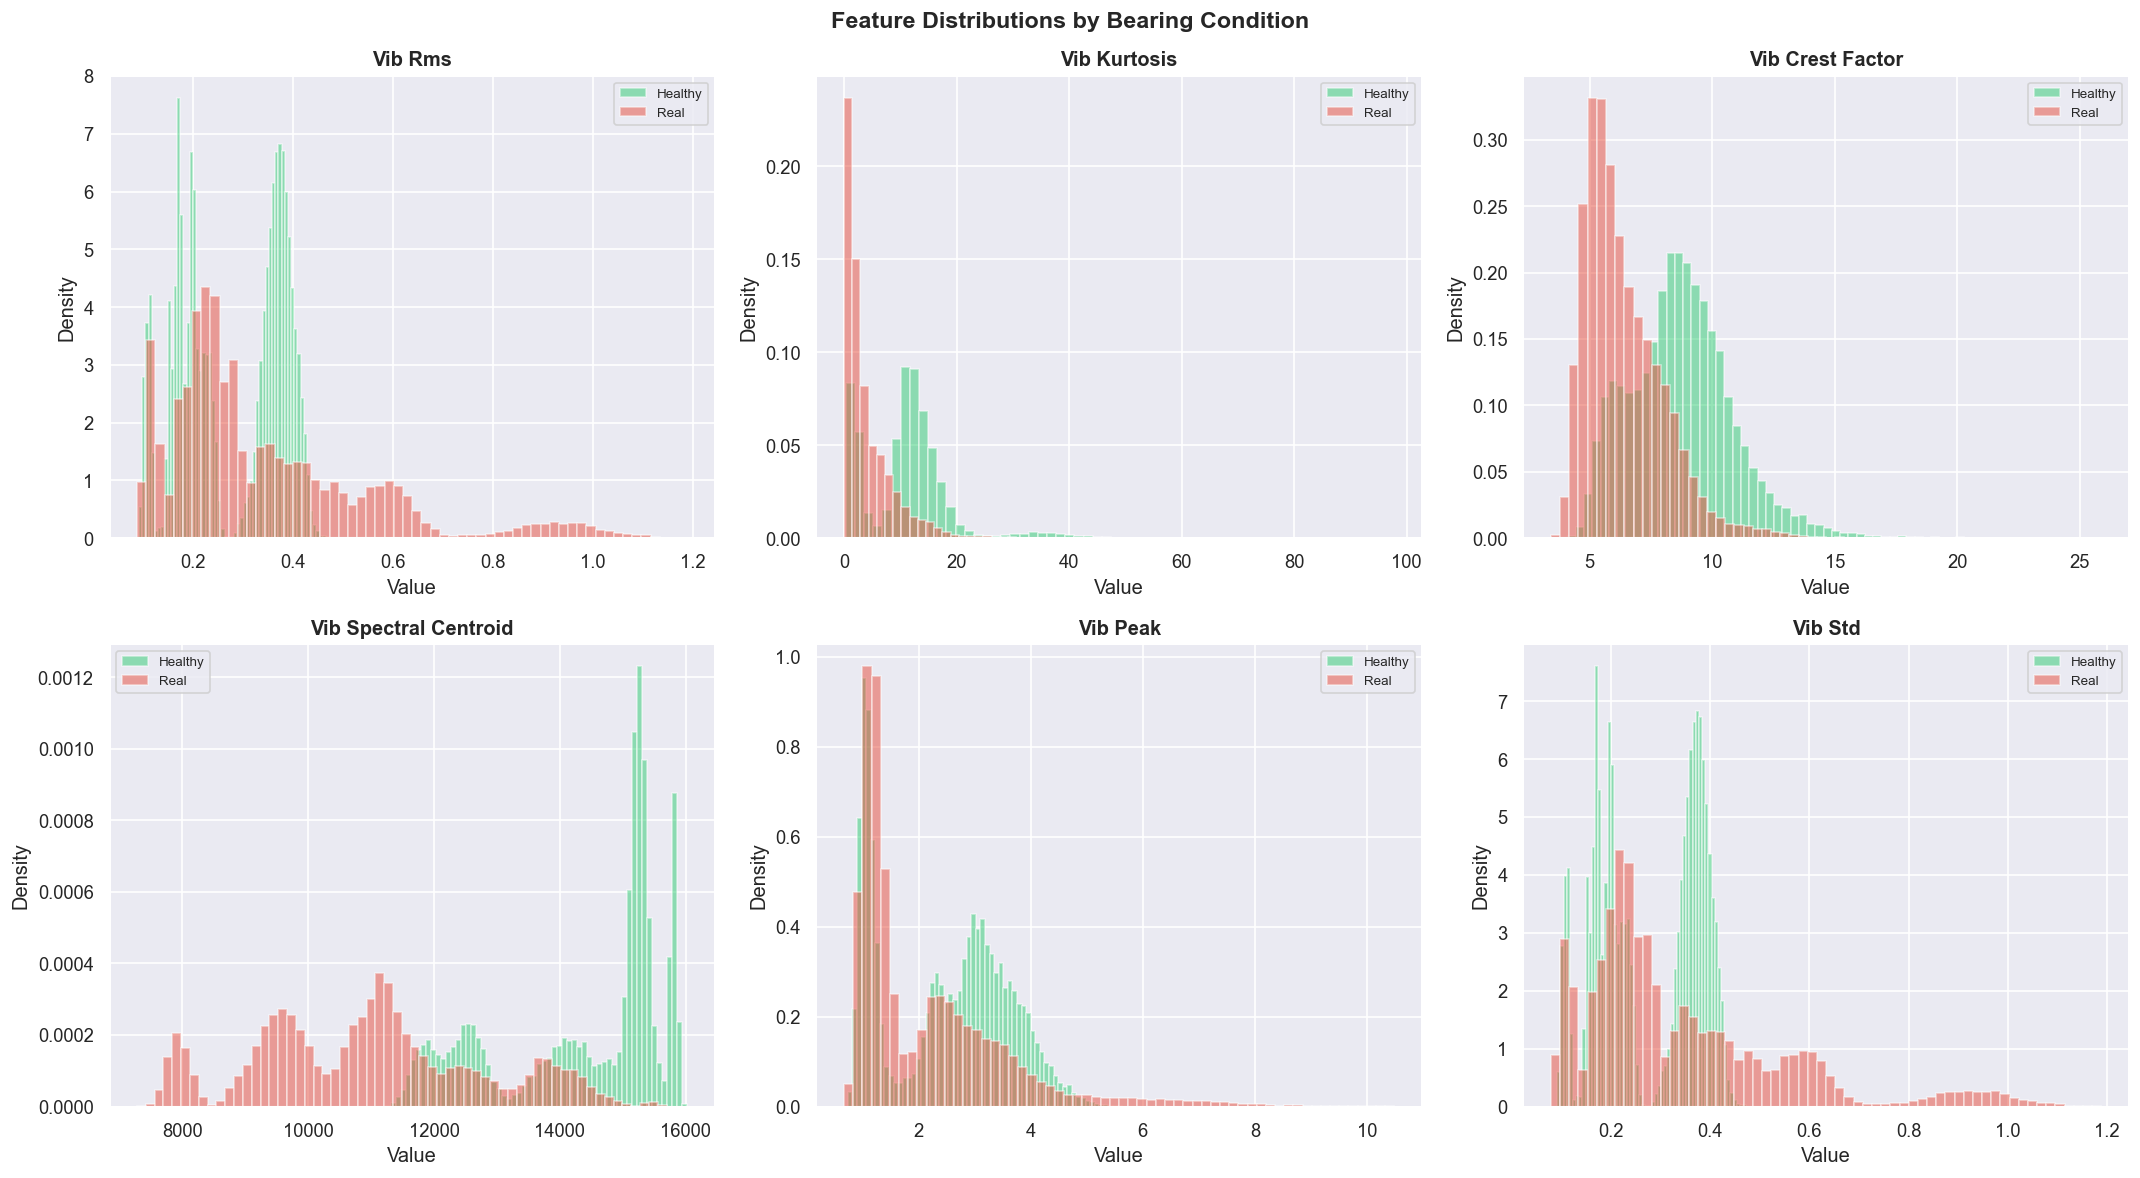

In [12]:
# Key features to visualize
key_features = ['vib_rms', 'vib_kurtosis', 'vib_crest_factor',
                 'vib_spectral_centroid', 'vib_peak', 'vib_std']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
palette = {'Healthy': '#2ecc71', 'Real': '#e74c3c'}

for ax, feat in zip(axes.flatten(), key_features):
    if feat not in master_df.columns:
        continue
    for label, color in palette.items():
        subset = master_df[master_df['label'] == label][feat].dropna()
        subset = subset[np.isfinite(subset)]
        ax.hist(subset, bins=60, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Bearing Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Box Plots — Kurtosis & RMS

C:\Users\Shaeel\AppData\Local\Temp\ipykernel_6292\2511817526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=plot_data, ax=ax,
C:\Users\Shaeel\AppData\Local\Temp\ipykernel_6292\2511817526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=plot_data, ax=ax,


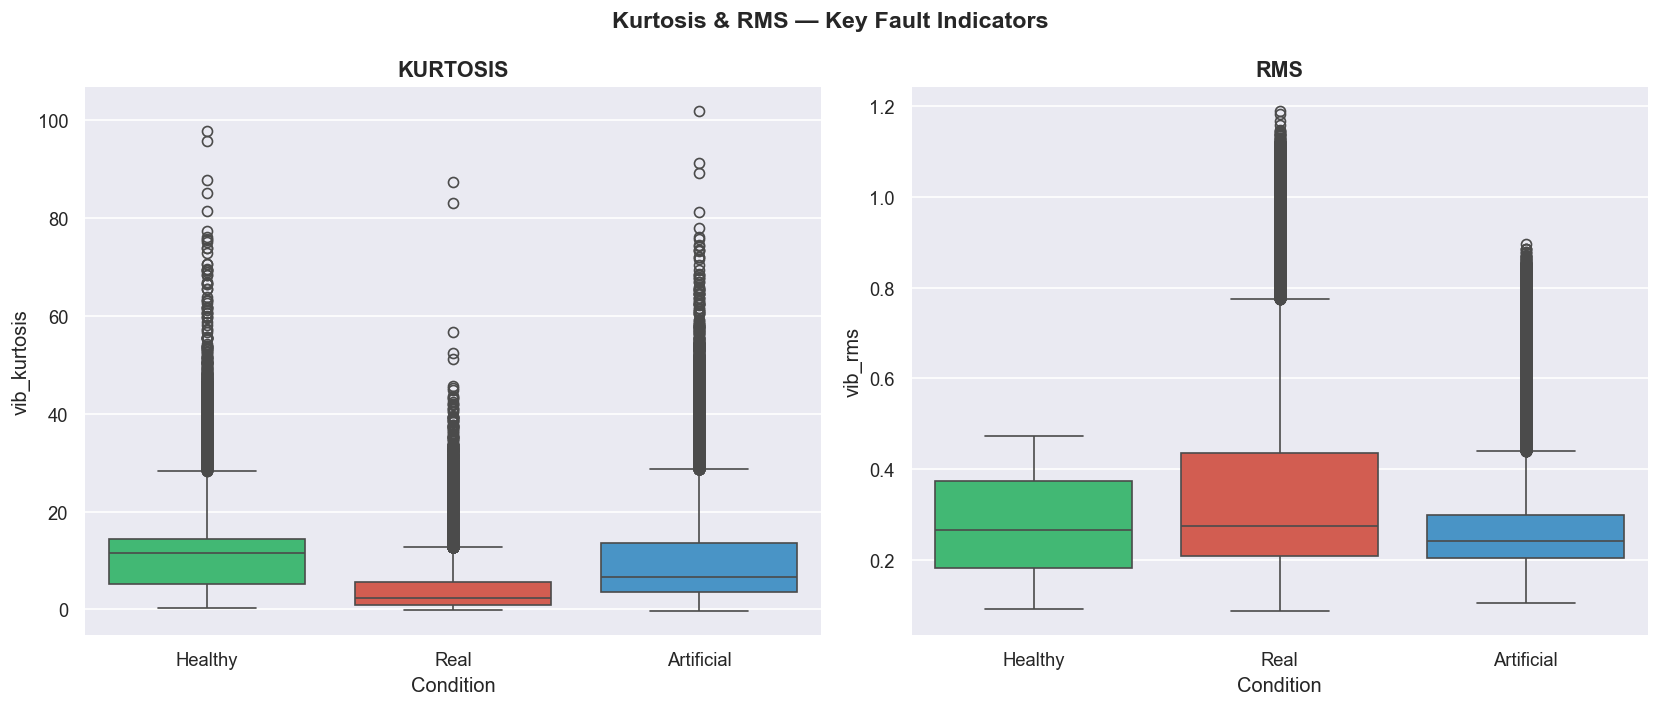

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feat in zip(axes, ['vib_kurtosis', 'vib_rms']):
    if feat not in master_df.columns:
        continue
    plot_data = master_df[['label', feat]].dropna()
    plot_data = plot_data[np.isfinite(plot_data[feat])]
    sns.boxplot(x='label', y=feat, data=plot_data, ax=ax,
                palette={'Healthy': '#2ecc71', 'Real': '#e74c3c','Artificial': '#3498db'},
                order=['Healthy', 'Real', 'Artificial'])
    ax.set_title(feat.replace('vib_', '').upper(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Condition')

plt.suptitle('Kurtosis & RMS — Key Fault Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Correlation Heatmap

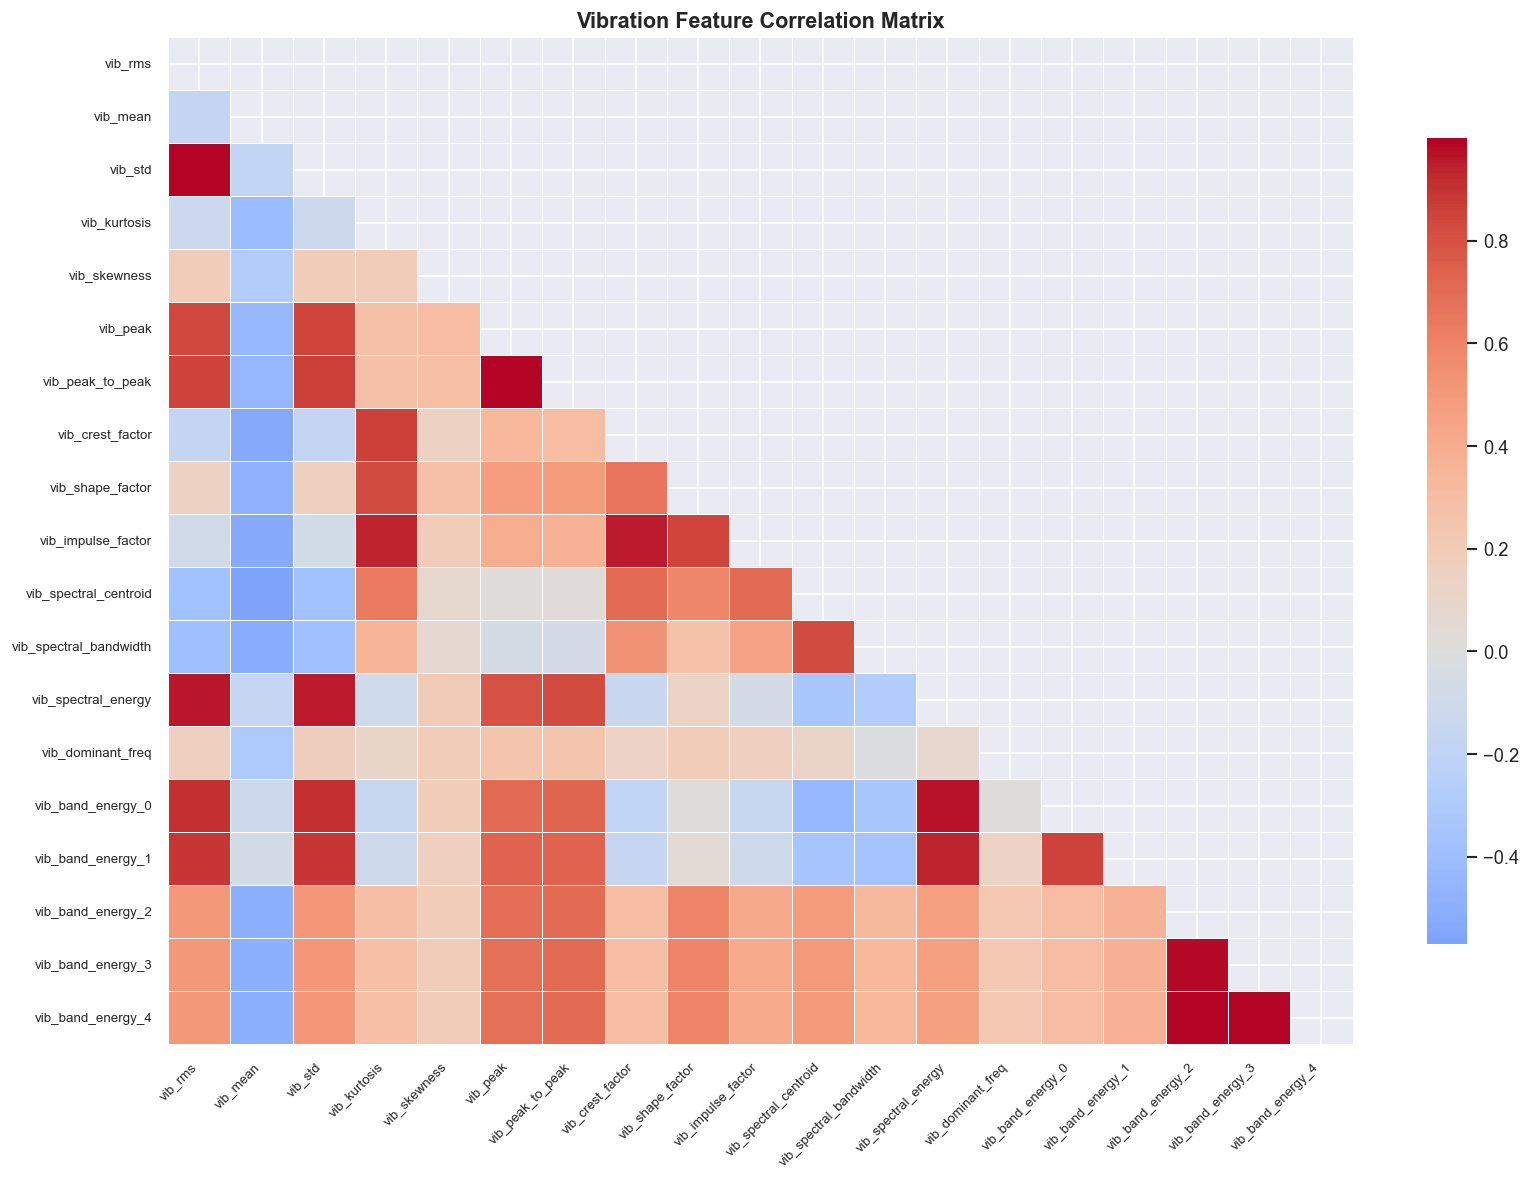

In [14]:
# Select numeric feature columns only
meta_cols = ['bearing_code','filename','label','location','damage_type','window_start']
numeric_df = master_df.drop(columns=meta_cols, errors='ignore').select_dtypes(include=[np.number])

# Correlation of key features
vib_cols = [c for c in numeric_df.columns if c.startswith('vib_')]
corr = numeric_df[vib_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Vibration Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Preprocessing — Cleaning & Encoding

In [15]:
meta_cols = [
    'bearing_code', 'filename', 'label', 'location', 
    'damage_type', 'window_start', 'condition', 
    'severity', 'label_enc', 'location_enc', 'damage_enc'
]

# Feature cols = everything else (all vib_, cur1_, cur2_ columns)
feature_cols = [col for col in master_df.columns if col not in meta_cols]
prediction_cols = ['severity', 'location_enc']

print(f'Total feature columns: {len(feature_cols)}')
print(feature_cols)

Total feature columns: 60
['vib_rms', 'vib_mean', 'vib_std', 'vib_kurtosis', 'vib_skewness', 'vib_peak', 'vib_peak_to_peak', 'vib_crest_factor', 'vib_shape_factor', 'vib_impulse_factor', 'vib_spectral_centroid', 'vib_spectral_bandwidth', 'vib_spectral_energy', 'vib_dominant_freq', 'vib_band_energy_0', 'vib_band_energy_1', 'vib_band_energy_2', 'vib_band_energy_3', 'vib_band_energy_4', 'cur1_rms', 'cur1_mean', 'cur1_std', 'cur1_kurtosis', 'cur1_skewness', 'cur1_peak', 'cur1_peak_to_peak', 'cur1_crest_factor', 'cur1_shape_factor', 'cur1_impulse_factor', 'cur1_spectral_centroid', 'cur1_spectral_bandwidth', 'cur1_spectral_energy', 'cur1_dominant_freq', 'cur1_band_energy_0', 'cur1_band_energy_1', 'cur1_band_energy_2', 'cur1_band_energy_3', 'cur1_band_energy_4', 'cur2_rms', 'cur2_mean', 'cur2_std', 'cur2_kurtosis', 'cur2_skewness', 'cur2_peak', 'cur2_peak_to_peak', 'cur2_crest_factor', 'cur2_shape_factor', 'cur2_impulse_factor', 'cur2_spectral_centroid', 'cur2_spectral_bandwidth', 'cur2_spect

In [16]:
master_df['damage_type'] = master_df['damage_type'].fillna('None')
master_df['location']    = master_df['location'].fillna('None')

In [17]:
# Label encoding for ML
le_label    = LabelEncoder()
le_location = LabelEncoder()
le_damage   = LabelEncoder()

master_df['label_enc']    = le_label.fit_transform(master_df['label'])
master_df['location_enc'] = le_location.fit_transform(master_df['location'])
master_df['damage_enc']   = le_damage.fit_transform(master_df['damage_type'])

print('Label Encoding Map:')
for enc, le in [('label', le_label), ('location', le_location), ('damage_type', le_damage)]:
    print(f'  {enc}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Label Encoding Map:
  label: {'Artificial': np.int64(0), 'Healthy': np.int64(1), 'Real': np.int64(2)}
  location: {'IR': np.int64(0), 'None': np.int64(1), 'OR': np.int64(2), 'OR+IR': np.int64(3)}
  damage_type: {'Drilling': np.int64(0), 'EDM': np.int64(1), 'Engraving': np.int64(2), 'Fatigue': np.int64(3), 'None': np.int64(4), 'Plastic Def.': np.int64(5)}


In [18]:
# Normalize feature columns
scaler = StandardScaler()
master_df_scaled = master_df.copy()
master_df_scaled[feature_cols] = scaler.fit_transform(master_df[feature_cols])

print('Feature scaling applied (StandardScaler).')
print(f'Final master_df shape: {master_df.shape}')
print(f'Scaled  master_df shape: {master_df_scaled.shape}')

Feature scaling applied (StandardScaler).
Final master_df shape: (196239, 71)
Scaled  master_df shape: (196239, 71)


## Summary

| Step | What was done |
|------|---------------|
| **Load** | Scanned all .mat files, parsed filenames for operating conditions |
| **Label** | Mapped bearing codes to Healthy / Artificial / Real + location + severity |
| **Window** | Applied sliding window (0.1s, 50% overlap) to all signals |
| **Features** | Extracted time-domain (RMS, Kurtosis, Crest Factor...) + frequency-domain (FFT, PSD bands, Centroid...) for vibration AND current signals |
| **EDA** | Raw signals, FFT, PSD, distribution histograms, box plots, correlation heatmap, PCA |
| **Preprocess** | Cleaned inf/NaN, label encoded, StandardScaler normalized |
| **Merge** | All 34 folders combined into single master DataFrame |
| **Save** | Exported as CSV and Parquet |
| **Sanity Check** | Random Forest baseline with feature importance |

**Next Steps:**
- Use the scaled parquet file to train LSTM / 1D-CNN for RUL prediction
- Focus on `Real` damage bearings (KA, KB, KI) for the car maintenance model
- Apply Wavelet denoising if signal noise is too high

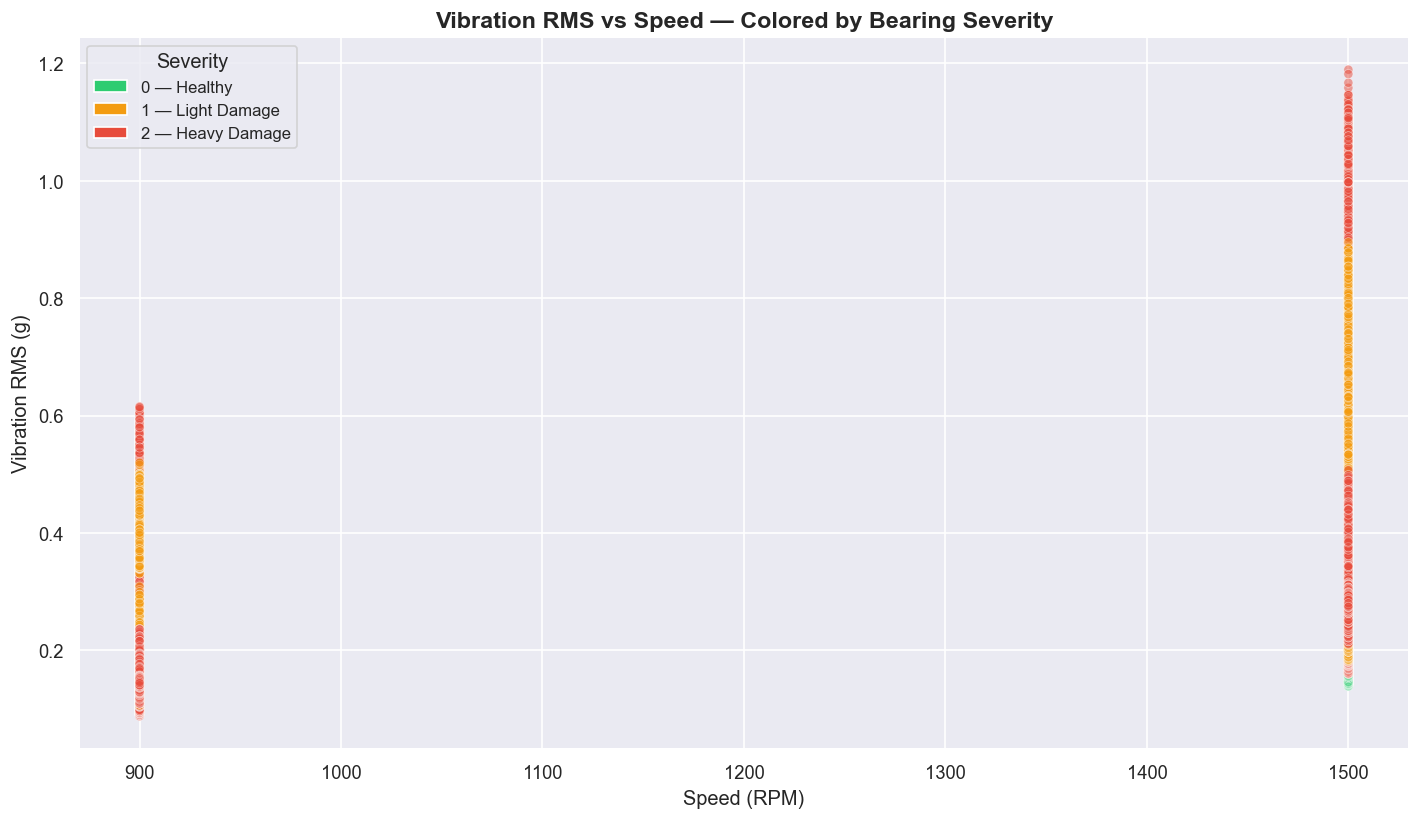

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

scatter = sns.scatterplot(
    data=master_df,
    x='speed_rpm',
    y='vib_rms',
    hue='severity',
    palette={0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'},
    alpha=0.5,
    s=30
)

# Labels
plt.title('Vibration RMS vs Speed — Colored by Bearing Severity', 
          fontsize=14, fontweight='bold')
plt.xlabel('Speed (RPM)', fontsize=12)
plt.ylabel('Vibration RMS (g)', fontsize=12)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='0 — Healthy'),
    Patch(facecolor='#f39c12', label='1 — Light Damage'),
    Patch(facecolor='#e74c3c', label='2 — Heavy Damage'),
]
plt.legend(handles=legend_elements, title='Severity', fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
requested_columns = {
    'shaft speed': 'speed_rpm',
    'load torque': 'torque_Nm',
    'radial force': 'force_N',
    'RMS': 'vib_rms',
    'kurtosis': 'vib_kurtosis',
    'crest factor': 'vib_crest_factor',
    'std deviation': 'vib_std',
    'peak amplitude': 'vib_peak',
    'Spectral Centroid[Hz]': 'vib_spectral_centroid',
    'Phase Current 1 RMS[A]': 'cur1_rms',
    'Phase Current 1 Kurtosis': 'cur1_kurtosis',
    'Phase Current 2 RMS[A]': 'cur2_rms',
}

print('Column presence check in master_df:')
for label, col in requested_columns.items():
    print(f'  - {label:<30}: {"FOUND" if col in master_df.columns else "MISSING"}')

print('\nCurrent dataset columns matching the request:')
found_cols = [col for col in requested_columns.values() if col in master_df.columns]
print(found_cols)

print('\nExample values for found columns:')
print(master_df_scaled[found_cols].iloc[:3])

Column presence check in master_df:
  - shaft speed                   : FOUND
  - load torque                   : FOUND
  - radial force                  : FOUND
  - RMS                           : FOUND
  - kurtosis                      : FOUND
  - crest factor                  : FOUND
  - std deviation                 : FOUND
  - peak amplitude                : FOUND
  - Spectral Centroid[Hz]         : FOUND
  - Phase Current 1 RMS[A]        : FOUND
  - Phase Current 1 Kurtosis      : FOUND
  - Phase Current 2 RMS[A]        : FOUND

Current dataset columns matching the request:
['speed_rpm', 'torque_Nm', 'force_N', 'vib_rms', 'vib_kurtosis', 'vib_crest_factor', 'vib_std', 'vib_peak', 'vib_spectral_centroid', 'cur1_rms', 'cur1_kurtosis', 'cur2_rms']

Example values for found columns:
   speed_rpm  torque_Nm   force_N   vib_rms  vib_kurtosis  vib_crest_factor  \
0  -1.732398   0.576929  0.577752  0.551368      1.215690          0.700869   
1  -1.732398   0.576929  0.577752  0.190001   

In [21]:
len(master_df_scaled.columns)

71

In [22]:
master_df_scaled['location']

0         None
1         None
2         None
3         None
4         None
          ... 
196234      IR
196235      IR
196236      IR
196237      IR
196238      IR
Name: location, Length: 196239, dtype: str

In [23]:
master_df_scaled['location_enc']

0         1
1         1
2         1
3         1
4         1
         ..
196234    0
196235    0
196236    0
196237    0
196238    0
Name: location_enc, Length: 196239, dtype: int64

In [24]:
X = master_df_scaled[feature_cols].values
y1 = master_df['severity'].values
y2 = master_df['location_enc'].values
y3 = master_df['damage_enc'].values

In [25]:
from sklearn.decomposition import PCA

# 1. Initialize the PCA instance
# Starting with 5 components is a great way to "break" the 100% accuracy
pca = PCA(n_components=5)

# 2. Fit and transform ONLY your feature columns (X)
# Use your scaled features, not the whole master_df
X_pca = pca.fit_transform(X) 

# 3. Check how much information you kept
print(f"Total variance explained by 5 components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Total variance explained by 5 components: 74.59%


In [26]:
from sklearn.model_selection import train_test_split

# Combine labels just to ensure the split sees all unique cases
combined_y = np.array([f"{a}_{b}_{c}" for a, b, c in zip(y1, y2, y3)])

# Split the PCA features
X_train, X_test, y_train_str, y_test_str, indices_train, indices_test = train_test_split(
    X_pca, combined_y, np.arange(len(X_pca)),
    test_size=0.2,
    random_state=42,
    stratify=combined_y  # This is the "magic" that prevents 0% accuracy
)

# Pull the actual numeric Y values for the model using the indices
y1_train, y1_test = y1[indices_train], y1[indices_test]
y2_train, y2_test = y2[indices_train], y2[indices_test]
y3_train, y3_test = y3[indices_train], y3[indices_test]

In [27]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the model with constraints to prevent 100% accuracy
base_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
multi_model = MultiOutputClassifier(base_rf)

# Stack the training targets
Y_train_stacked = np.column_stack((y1_train, y2_train, y3_train))

# Fit the model on PCA components
multi_model.fit(X_train, Y_train_stacked)

# Predict on the PCA test set
predictions = multi_model.predict(X_test)

In [28]:
from sklearn.metrics import classification_report
targets = ['Severity', 'Location', 'Damage']
for i, name in enumerate(targets):
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(np.column_stack((y1_test, y2_test, y3_test))[:, i], predictions[:, i]))


=== Severity Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      7593
           1       0.91      0.83      0.87     11397
           2       0.91      0.97      0.94     20258

    accuracy                           0.92     39248
   macro avg       0.93      0.92      0.92     39248
weighted avg       0.92      0.92      0.92     39248


=== Location Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     12672
           1       0.98      0.93      0.95      7593
           2       0.93      0.92      0.93     15183
           3       0.98      0.84      0.90      3800

    accuracy                           0.92     39248
   macro avg       0.94      0.91      0.92     39248
weighted avg       0.92      0.92      0.92     39248


=== Damage Classification Report ===
              precision    recall  f1-score   support

           

In [ ]:
import joblib

# Save the entire pipeline (PCA + MultiOutput Classifier)
joblib.dump(multi_model, 'bearing_diagnostic_model_v1.pkl')

# 1. Export the fitted scaler (assuming it was called 'scaler')
joblib.dump(scaler, 'bearing_scaler.pkl') #

# 2. Export the fitted PCA instance
joblib.dump(pca, 'bearing_pca.pkl') #


['bearing_pca.pkl']

In [ ]:
from sklearn.model_selection import train_test_split,cross_validate

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler # Requires: pip install imbalanced-learn

# 1. Combine targets to ensure stratification across all three
# This helps prevent the "missing classes" issue in your test set
combined_y = np.array([f"{a}_{b}_{c}" for a, b, c in zip(y1, y2, y3)])

# 2. Split with stratification on the combined labels
X_train, X_test, y_train_combined, y_test_combined, indices_train, indices_test = train_test_split(
    X, combined_y, np.arange(len(X)), 
    test_size=0.3, 
    random_state=42, 
    stratify=combined_y
)

# Unpack original targets using the indices
y1_train, y1_test = y1[indices_train], y1[indices_test]
y2_train, y2_test = y2[indices_train], y2[indices_test]
y3_train, y3_test = y3[indices_train], y3[indices_test]

# 3. Handle the "Missing Classes" by Oversampling the Training Set
# This clones rare samples so the model doesn't give 0% accuracy on them
ros = RandomOverSampler(random_state=42)
Y_train_stacked = np.column_stack((y1_train, y2_train, y3_train))
X_resampled, Y_resampled = ros.fit_resample(X_train, y_train_combined)

# Resplit the oversampled combined target back into y1, y2, y3
# (Each row in Y_resampled is now a string like "0_1_2")
y1_res = np.array([s.split('_')[0] for s in Y_resampled]).astype(int)
y2_res = np.array([s.split('_')[1] for s in Y_resampled]).astype(int)
y3_res = np.array([s.split('_')[2] for s in Y_resampled]).astype(int)

# 4. Define the Multi-Output Model
# We set 'max_depth' and 'min_samples_leaf' to force the model to stop memorizing
forest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,        # LIMIT DEPTH: This is what breaks the 100% accuracy
    min_samples_leaf=5,  # Forces general patterns instead of specific rows
    random_state=42,
    n_jobs=-1
)

model = MultiOutputClassifier(forest)

# 5. Fit the model
model.fit(X_resampled, np.column_stack((y1_res, y2_res, y3_res)))

# 6. Predict and Evaluate
predictions = model.predict(X_test)

targets = ['Severity', 'Location', 'Damage']
for i, name in enumerate(targets):
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(np.column_stack((y1_test, y2_test, y3_test))[:, i], predictions[:, i]))


=== Severity Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     11389
           1       0.99      0.99      0.99     17095
           2       0.99      1.00      1.00     30388

    accuracy                           0.99     58872
   macro avg       0.99      0.99      0.99     58872
weighted avg       0.99      0.99      0.99     58872


=== Location Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     19009
           1       1.00      0.95      0.97     11389
           2       0.99      1.00      1.00     22774
           3       1.00      1.00      1.00      5700

    accuracy                           0.99     58872
   macro avg       0.99      0.99      0.99     58872
weighted avg       0.99      0.99      0.99     58872


=== Damage Classification Report ===
              precision    recall  f1-score   support

           

In [ ]:
x_train, x_test, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test = train_test_split(
    X, y1, y2, y3, 
    random_state=42, 
    test_size=0.4,
    stratify=y3  # stratify on damage type since it has rarest classes
    
)


In [ ]:
if not os.path.exists('./paderborn_features_scaled.csv'):
    master_df.to_csv('./paderborn_features_raw.csv', index=False)
    print('Master DataFrame saved to ./paderborn_features_raw.csv')
    master_df_scaled.to_csv('./paderborn_features_scaled.csv', index=False)
    print('Scaled DataFrame saved to ./paderborn_features_scaled.csv')

In [ ]:
# from sklearn.model_selection import StratifiedGroupKFold
# import numpy as np

# # Create the stratification target
# combined_y = y1.astype(str) + '_' + y2.astype(str) + '_' + y3.astype(str)
# groups = master_df['bearing_code'].values
# unique_classes = np.unique(combined_y)

# found_valid_split = False
# seed = 42

# while not found_valid_split:
#     sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    
#     for train_idx, test_idx in sgkf.split(X, combined_y, groups):
#         # Check if all classes are present in both sets
#         train_labels = set(combined_y[train_idx])
#         test_labels = set(combined_y[test_idx])
        
#         if len(train_labels) == len(unique_classes) and len(test_labels) == len(unique_classes):
#             found_valid_split = True
#             break # Valid fold found
            
#     if not found_valid_split:
#         seed += 1 # Try a new seed if the split failed
#         if seed > 1000: # Safety break
#             print("Impossible to split perfectly with current group constraints.")
#             break

# # Final Assignments
# x_train, x_test = X[train_idx], X[test_idx]
# y1_train, y1_test = y1[train_idx], y1[test_idx]
# y2_train, y2_test = y2[train_idx], y2[test_idx]
# y3_train, y3_test = y3[train_idx], y3[test_idx]

# print(f"✅ Valid split found at seed {seed}")
# print(f"Test classes: {len(np.unique(combined_y[test_idx]))} / {len(unique_classes)}")

In [ ]:
# from sklearn.model_selection import StratifiedGroupKFold
# import numpy as np

# # Use StratifiedGroupKFold instead
# sgkf = StratifiedGroupKFold(n_splits=5)

# groups = master_df['bearing_code'].values

# # Take first fold as train/test
# for train_idx, test_idx in sgkf.split(X, y1, groups):
#     break  # just take first split

# x_train, x_test = X[train_idx], X[test_idx]
# y1_train, y1_test = y1[train_idx], y1[test_idx]
# y2_train, y2_test = y2[train_idx], y2[test_idx]
# y3_train, y3_test = y3[train_idx], y3[test_idx]

# print('Train bearings:', master_df.iloc[train_idx]['bearing_code'].unique())
# print('Test bearings: ', master_df.iloc[test_idx]['bearing_code'].unique())
# print('\nSeverity distribution in test:')
# print(pd.Series(y1_test).value_counts())

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Create a combined label for stratification purposes
# This treats each unique combination of y1, y2, and y3 as a single class
combined_y = y1.astype(str) + "_" + y2.astype(str) + "_" + y3.astype(str)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, combined_y):
    x_train, x_test = X[train_idx], X[test_idx]
    y1_train, y1_test = y1[train_idx], y1[test_idx]
    y2_train, y2_test = y2[train_idx], y2[test_idx]
    y3_train, y3_test = y3[train_idx], y3[test_idx]
    
    # Train your multi-output model here

In [ ]:
master_df.duplicated().sum()

np.int64(0)

In [ ]:
master_df_scaled['severity'].value_counts() 

severity
2    101294
1     56982
0     37963
Name: count, dtype: int64

In [ ]:
master_df_scaled['location'].value_counts() 

location
OR       75914
IR       63363
None     37963
OR+IR    18999
Name: count, dtype: int64

In [ ]:
master_df_scaled['damage_type'].value_counts() 

damage_type
Fatigue         76007
EDM             38038
None            37963
Drilling        18996
Engraving       18910
Plastic Def.     6325
Name: count, dtype: int64

In [ ]:
# Label Encoding Maps
print('=== Label Encoding Maps ===\n')

print('\ny2 — Location:')
for code, name in enumerate(le_location.classes_):
    print(f'  {code} = {name}')

print('\ny3 — Damage Type:')
for code, name in enumerate(le_damage.classes_):
    print(f'  {code} = {name}')

print('\nLabel (condition):')
for code, name in enumerate(le_label.classes_):
    print(f'  {code} = {name}')

=== Label Encoding Maps ===


y2 — Location:
  0 = IR
  1 = None
  2 = OR
  3 = OR+IR

y3 — Damage Type:
  0 = Drilling
  1 = EDM
  2 = Engraving
  3 = Fatigue
  4 = None
  5 = Plastic Def.

Label (condition):
  0 = Artificial
  1 = Healthy
  2 = Real


In [ ]:
master_df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(x_train, y1_train)

# Predict
y1_pred = knn.predict(x_test)

In [ ]:
knn2= KNeighborsClassifier(n_neighbors=5)
knn2.fit(x_train, y2_train)
y2_pred = knn2.predict(x_test)

In [ ]:
knn3 = KNeighborsClassifier(n_neighbors=5)
knn3.fit(x_train, y3_train)
y3_pred = knn3.predict(x_test)

In [ ]:
print('Classes in test set:', np.unique(y3_test))
print('All classes:', le_damage.classes_)

Classes in test set: [0 1 2 3 4 5]
All classes: ['Drilling' 'EDM' 'Engraving' 'Fatigue' 'None' 'Plastic Def.']


In [ ]:
print('=== Severity Classification Report ===\n')
print(classification_report(y1_test, y1_pred, 
      target_names=['Healthy', 'Light Damage', 'Heavy Damage']))
print('=== Location Classification Report ===\n')
print(classification_report(y2_test, y2_pred, target_names=le_location.classes_))
print('=== Damage Type Classification Report ===\n')
print(classification_report(y3_test, y3_pred, target_names=le_damage.classes_))

=== Severity Classification Report ===

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      7592
Light Damage       0.99      0.99      0.99     11397
Heavy Damage       0.99      1.00      1.00     20258

    accuracy                           0.99     39247
   macro avg       0.99      0.99      0.99     39247
weighted avg       0.99      0.99      0.99     39247

=== Location Classification Report ===

              precision    recall  f1-score   support

          IR       0.98      0.99      0.98     12672
        None       1.00      1.00      1.00      7592
          OR       0.99      0.99      0.99     15183
       OR+IR       1.00      1.00      1.00      3800

    accuracy                           0.99     39247
   macro avg       0.99      0.99      0.99     39247
weighted avg       0.99      0.99      0.99     39247

=== Damage Type Classification Report ===

              precision    recall  f1-score   support

    Dr

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y1_train)
y1_rf_pred = rf.predict(x_test)



In [ ]:
print('=== Random Forest Severity Classification Report ===\n')
print(classification_report(y1_test, y1_rf_pred,
      target_names=['Healthy', 'Light Damage', 'Heavy Damage']))

=== Random Forest Severity Classification Report ===

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      7592
Light Damage       1.00      1.00      1.00     11397
Heavy Damage       1.00      1.00      1.00     20258

    accuracy                           1.00     39247
   macro avg       1.00      1.00      1.00     39247
weighted avg       1.00      1.00      1.00     39247



In [ ]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(x_train, y2_train)
y2_rf2_pred = rf2.predict(x_test)

KeyboardInterrupt: 

In [ ]:
print('=== Random Forest Severity Classification Report ===\n')
print(classification_report(y2_test, y2_rf2_pred,
      target_names=le_location.classes_))

=== Random Forest Severity Classification Report ===

              precision    recall  f1-score   support

          IR       1.00      1.00      1.00     25454
        None       1.00      1.00      1.00     15185
          OR       1.00      1.00      1.00     30383
       OR+IR       1.00      1.00      1.00      7474

    accuracy                           1.00     78496
   macro avg       1.00      1.00      1.00     78496
weighted avg       1.00      1.00      1.00     78496



In [ ]:
rf3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf3.fit(x_train, y3_train)
y3_rf3_pred = rf3.predict(x_test)


KeyboardInterrupt: 

In [ ]:
print('=== Severity Classification Report ===\n')
print(classification_report(y3_test, y3_rf3_pred,
      target_names=le_damage.classes_))

=== Severity Classification Report ===

              precision    recall  f1-score   support

    Drilling       0.37      0.50      0.42      3205
         EDM       0.00      0.00      0.00      3200
   Engraving       0.08      0.12      0.10      3162
     Fatigue       0.51      1.00      0.67      3222
        None       0.96      0.99      0.98      3202
Plastic Def.       0.00      0.00      0.00      3201

    accuracy                           0.44     19192
   macro avg       0.32      0.44      0.36     19192
weighted avg       0.32      0.44      0.36     19192



f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import xgboost as xgb

In [ ]:
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(x_train, y1_train)
y1_xgb_pred = xgb_clf.predict(x_test)


f:\IDS\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:23:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
xgb_clf2= xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf2.fit(x_train, y2_train)
y2_xgb_pred = xgb_clf2.predict(x_test)

f:\IDS\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:23:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(x_train, y3_train)
y3_xgb_pred = xgb_clf.predict(x_test)

f:\IDS\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:08:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("Classification report")
print(classification_report(y1_test, y1_xgb_pred, target_names=['Healthy', 'Light Damage', 'Heavy Damage']))
print("Classification report")
print(classification_report(y2_test, y2_xgb_pred, target_names=le_location.classes_))
print("Classification report")
print(classification_report(y3_test, y3_xgb_pred, target_names=le_damage.classes_))

Classification report
              precision    recall  f1-score   support

     Healthy       0.94      0.97      0.96      3202
Light Damage       0.00      0.00      0.00      6405
Heavy Damage       0.60      0.98      0.74      9585

    accuracy                           0.65     19192
   macro avg       0.51      0.65      0.57     19192
weighted avg       0.45      0.65      0.53     19192

Classification report
              precision    recall  f1-score   support

          IR       0.47      0.42      0.44      6422
        None       0.94      0.99      0.96      3202
          OR       0.80      0.66      0.72      9568
       OR+IR       0.00      0.00      0.00         0

    accuracy                           0.64     19192
   macro avg       0.55      0.52      0.53     19192
weighted avg       0.71      0.64      0.67     19192

Classification report
              precision    recall  f1-score   support

    Drilling       0.30      0.37      0.33      3205
         

f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\IDS\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: 